In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt

Text(0.5, 1.0, 'Wigner function')

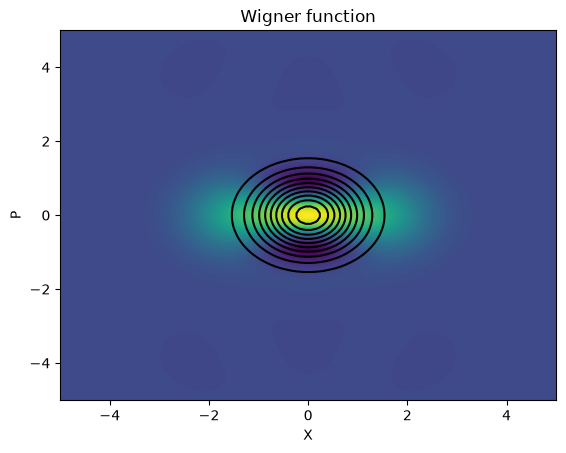

In [ ]:
#coherent state from qutip
alpha = 1
N = 10
coherent_state = qt.coherent(N, alpha) + qt.coherent(N, -alpha)
fock_state = qt.fock(N, 0)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner = qt.wigner(coherent_state, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
fock_wigner = qt.wigner(fock_state, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), coherent_wigner, 100)
ax.contour(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), fock_wigner, 10, colors='k')
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')

Visualizing the overlap of quadrature measurements of two coherent states

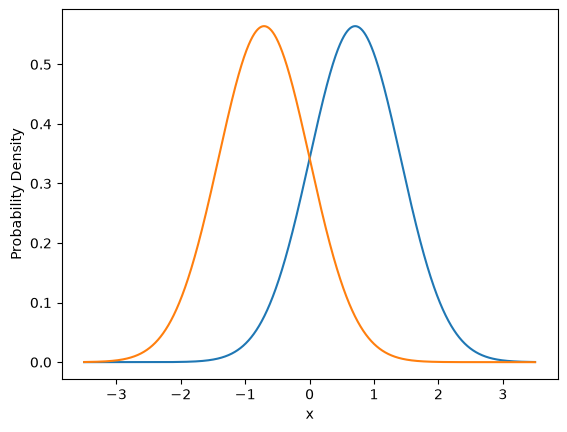

In [ ]:
#coherent state from qutip
alpha = 0.5
N = 100
size = 10000
axis_size = alpha*3+2
coherent_state = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
xvec = np.linspace(-axis_size, axis_size, size)
wf = qt.distributions.HarmonicOscillatorWaveFunction(coherent_state, extent=[-axis_size, axis_size], steps=size)
wf2 = qt.distributions.HarmonicOscillatorWaveFunction(coherent_state2, extent=[-axis_size, axis_size], steps=size)
xvec, wvec2 = wf.xvecs[0], wf2.xvecs[0]
psi_x, psi_x2 = wf.data, wf2.data
probabilities = np.abs(psi_x)**2
probabilities2 = np.abs(psi_x2)**2

plt.plot(xvec, probabilities, label='Coherent State')
plt.plot(xvec, probabilities2, label='Coherent State (Conjugate)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.show()

Visualizing the overlap of two coherent states with displacement and measurement in the photon number basis

Text(0.5, 1.0, 'Photon Number Distributions for Coherent States')

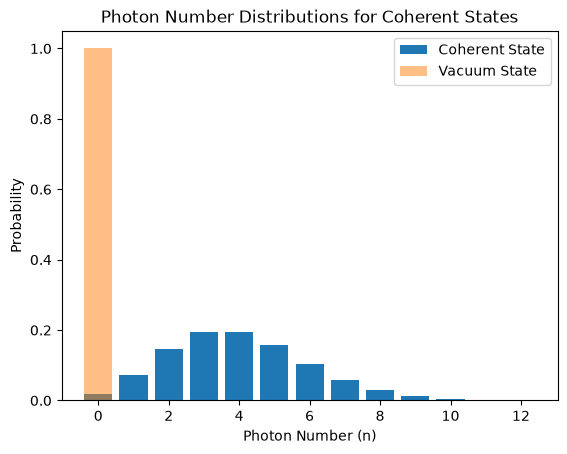

In [40]:
#coherent state from qutip
alpha = 1
N = int((alpha*1.7+2)**2)
size = N
axis_size = alpha*3+2
coherent_state = qt.coherent(N, 2*alpha)
coherent_state2 = qt.coherent(N, 0)
xvec = np.linspace(-axis_size, axis_size, size)
nvec = np.arange(N)
probabilities = np.abs(coherent_state.full().flatten())**2
probabilities2 = np.abs(coherent_state2.full().flatten())**2


plt.bar(nvec[:size], probabilities, width=0.8, label='Coherent State')
plt.bar(nvec[:size], probabilities2, width=0.8, label='Vacuum State',alpha=0.5)
plt.xlabel('Photon Number (n)')
plt.ylabel('Probability')
plt.legend()
plt.title('Photon Number Distributions for Coherent States')

## Guessing Criteria:

### Best Guess Criterion:

Always give the best guess of either 0 or 1 for a given measurement. Error rate $P_e = P(0)P(1|0) + P(1)(0|1)$

### Decision with Inconclusive Results: (P(Null)) We don't do this yet but we will later

Mode A: Unambigious State Discrimination, $P_e = 0$ highly unpractical for us at times

Mode B: Error-erasure compromise. Can have all 3 where P(Null) is simply an erasure

Below I calculate for the theoretical values for a Kennedy reciever with the mathematics behind it:

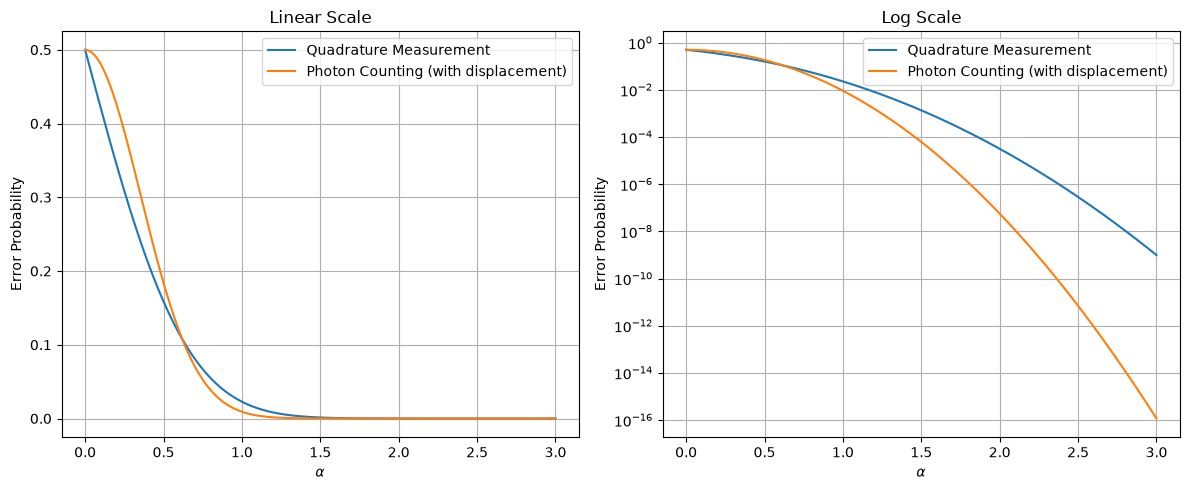

In [52]:
def best_guess_quadrature(alpha): #For best guess criterion
    p_error = 0.5 * (1.0 - sp.special.erf(np.sqrt(2) * alpha))
    return p_error
def best_guess_photon_count(alpha):
    p_error = 0.5 * np.exp(-4 * alpha**2)
    return p_error

alphas = np.linspace(0, 3, 200)
p_errors_quad = [best_guess_quadrature(a) for a in alphas]
p_errors_photon = [best_guess_photon_count(a) for a in alphas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale plot
ax1.plot(alphas, p_errors_quad, label='Quadrature Measurement')
ax1.plot(alphas, p_errors_photon, label='Photon Counting (with displacement)')
ax1.set_xlabel(r'$\alpha$')
ax1.set_ylabel('Error Probability')
ax1.set_title('Linear Scale')
ax1.legend()
ax1.grid(True)

# Log scale plot
ax2.semilogy(alphas, p_errors_quad, label='Quadrature Measurement')
ax2.semilogy(alphas, p_errors_photon, label='Photon Counting (with displacement)')
ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel('Error Probability')
ax2.set_title('Log Scale')
ax2.legend()
ax2.grid(True, which='both')

plt.tight_layout()
plt.show()

Now I will make commands to show the mathematics of using a Dolinar Reciever instead:

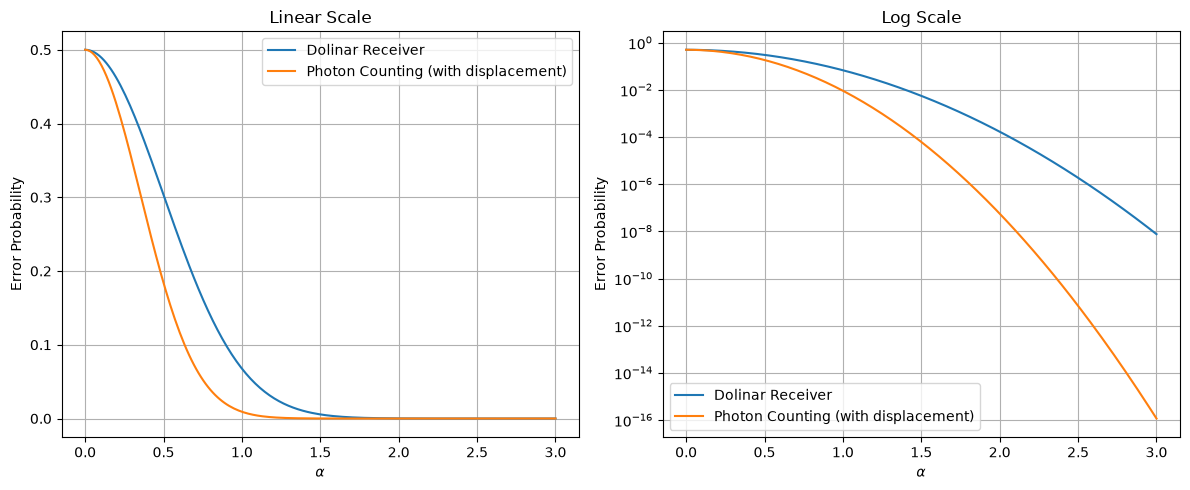

In [59]:
def dolinar_reciever_odds(alpha, branches):
    eff_alpha = alpha / np.sqrt(branches)
    err = np.exp(-4 * eff_alpha**2)
    right_tests = branches/2 #when D is correct, so there's err chance of a wrong
    all_err = err**(right_tests) #when D is wrong, so there's 1-err chance of a wrong
    return all_err/2

alphas = np.linspace(0, 3, 200)
p_errors_photon = [best_guess_photon_count(a) for a in alphas]
p_errors_dolinar = [dolinar_reciever_odds(a, 100) for a in alphas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale plot
ax1.plot(alphas, p_errors_dolinar, label='Dolinar Receiver')
ax1.plot(alphas, p_errors_photon, label='Photon Counting (with displacement)')
ax1.set_xlabel(r'$\alpha$')
ax1.set_ylabel('Error Probability')
ax1.set_title('Linear Scale')
ax1.legend()
ax1.grid(True)

# Log scale plot
ax2.semilogy(alphas, p_errors_dolinar, label='Dolinar Receiver')
ax2.semilogy(alphas, p_errors_photon, label='Photon Counting (with displacement)')
ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel('Error Probability')
ax2.set_title('Log Scale')
ax2.legend()
ax2.grid(True, which='both')

plt.tight_layout()
plt.show()

While displacing by $\alpha$ seems to be significantly better than quadrature measurements, there should theoretically be a displacement of $\alpha + \beta$ inwhich would be slightly better as it would mean a higher chance of measuring a photon given the correct displacement and if it's small enough we can still minimize the odds of getting a false positive. So we will optimize to minimize our $P_e = (1-e^{-\beta^2} + e^{-(2\alpha + \beta)^2})/2$ which is the error for a kennedy reciever then.

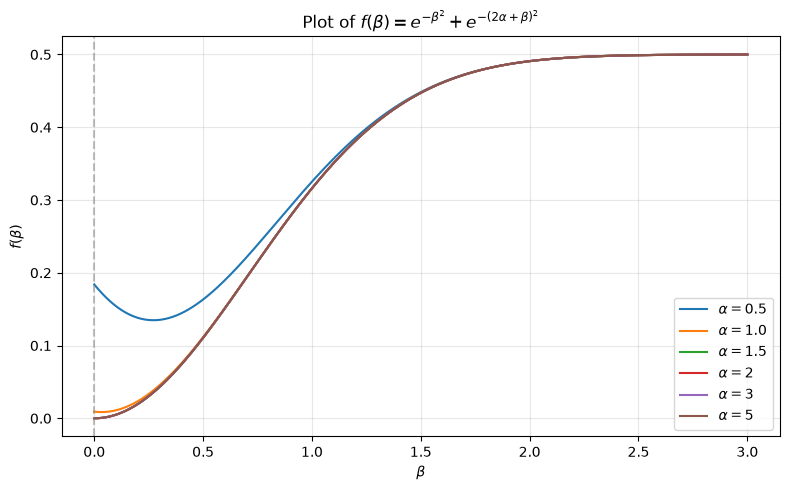

In [69]:
def f(beta, alpha):
    return (1 - np.exp(-beta**2) + np.exp(-(2*alpha + beta)**2))/2

beta_vals = np.linspace(0, 3, 500)
alphas = [0.5, 1.0, 1.5,2,3,5]

plt.figure(figsize=(8, 5))
for alpha in alphas:
    plt.plot(beta_vals, f(beta_vals, alpha), label=f'$\\alpha = {alpha}$')

plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title(r'Plot of $f(\beta) = e^{-\beta^2} + e^{-(2\alpha + \beta)^2}$')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$f(\beta)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot.png')


Using optimal $\beta$ for kennedy recieverrison to the default displacement

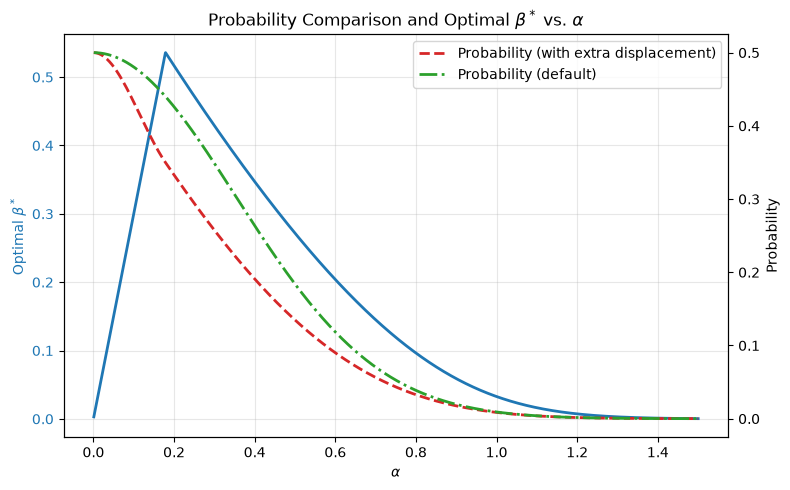

In [ ]:
# Range of alpha values
alpha_vals = np.linspace(0.001, 1.5, 3000)

optimal_betas = []
min_values = []

def minimize_f_for_alpha(alpha):
    res = sp.optimize.minimize_scalar(
        lambda b: f(b, alpha), bounds=(-3 * alpha, 3 * alpha), method="bounded"
    )
    return res.x, res.fun
for a in alpha_vals:
  # Using bounded optimization over a reasonable search interval
    res = sp.optimize.minimize_scalar(
        lambda b: f(b, a), bounds=(-3 * a, 3 * a), method="bounded"
    )
    optimal_betas.append(res.x)
    min_values.append(res.fun)

# Default reference probability
default_prob = 1/2*np.exp(-4 * alpha_vals**2)

# Plotting the results
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot optimal beta
color = "tab:blue"
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel(r"Optimal $\beta^*$", color=color)
ax1.plot(alpha_vals, optimal_betas, color=color, lw=2, label=r"$\beta^*$")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot probability values on twin axis
ax2 = ax1.twinx()
ax2.set_ylabel("Probability", color="black")
(line1,) = ax2.plot(
    alpha_vals,
    min_values,
    color="tab:red",
    lw=2,
    linestyle="--",
    label="Probability (with extra displacement)",
)
(line2,) = ax2.plot(
    alpha_vals,
    default_prob,
    color="tab:green",
    lw=2,
    linestyle="-.",
    label="Probability (default)",
)
ax2.tick_params(axis="y", labelcolor="black")

# Combined legend for probability lines
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax2.legend(lines, labels, loc="upper right")

plt.title(r"Probability Comparison and Optimal $\beta^*$ vs. $\alpha$")
fig.tight_layout()
plt.show()

In [ ]:
def f2optimize(alpha, p0, p1):
    res = sp.optimize.minimize_scalar(
        lambda beta: p0 * (1 - np.exp(-(-alpha + beta)**2)) + p1 * (np.exp(-(alpha + beta)**2)), bounds=(-3 * alpha, 3 * alpha), method="bounded"
    )
    return res

def update_probabilities(p0,beta,alpha,click): #p0 is old hypothesis
    if click == 1:
        L0 = 1.0 - np.exp(-((alpha + beta) ** 2))
        L1 = 1.0 - np.exp(-((-alpha + beta) ** 2))
    else:
        L0 = np.exp(-((alpha + beta) ** 2))
        L1 = np.exp(-((-alpha + beta) ** 2))
    p0_new = L0 / (L0 + L1)

    return p0_new, 1-p0_new

def odds_optimized_dolinar(alpha, branches):
    res = sp.optimize.minimize_scalar(
            lambda b: f(b, a), bounds=(-3 * a, 3 * a), method="bounded"
        )
    # optimal_beta = res.x
    

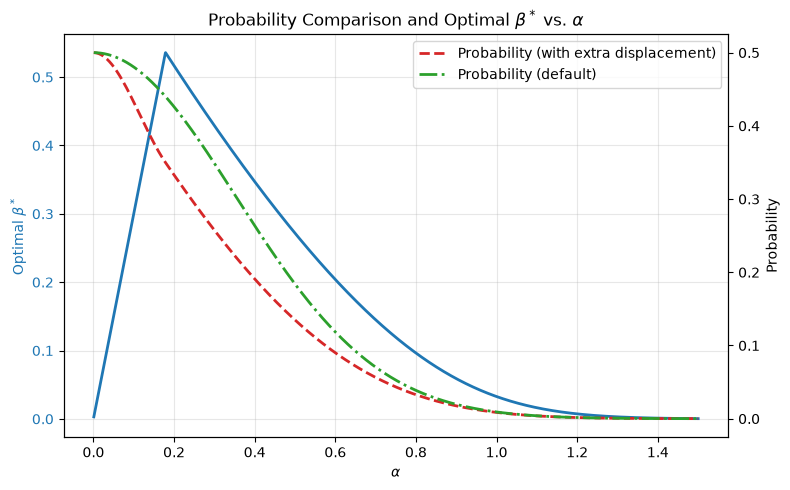

In [82]:
# Range of alpha values
alpha_vals = np.linspace(0.001, 1.5, 3000)

optimal_betas = []
min_values = []

def minimize_f_for_alpha(alpha):
    res = sp.optimize.minimize_scalar(
        lambda b: f(b, alpha), bounds=(-3 * alpha, 3 * alpha), method="bounded"
    )
    return res.x, res.fun
for a in alpha_vals:
  # Using bounded optimization over a reasonable search interval
    res = f2optimize(a, 0.5, 0.5)
    optimal_betas.append(res.x)
    min_values.append(res.fun)

# Default reference probability
default_prob = 1/2*np.exp(-4 * alpha_vals**2)

# Plotting the results
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot optimal beta
color = "tab:blue"
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel(r"Optimal $\beta^*$", color=color)
ax1.plot(alpha_vals, optimal_betas, color=color, lw=2, label=r"$\beta^*$")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot probability values on twin axis
ax2 = ax1.twinx()
ax2.set_ylabel("Probability", color="black")
(line1,) = ax2.plot(
    alpha_vals,
    min_values,
    color="tab:red",
    lw=2,
    linestyle="--",
    label="Probability (with extra displacement)",
)
(line2,) = ax2.plot(
    alpha_vals,
    default_prob,
    color="tab:green",
    lw=2,
    linestyle="-.",
    label="Probability (default)",
)
ax2.tick_params(axis="y", labelcolor="black")

# Combined legend for probability lines
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax2.legend(lines, labels, loc="upper right")

plt.title(r"Probability Comparison and Optimal $\beta^*$ vs. $\alpha$")
fig.tight_layout()
plt.show()

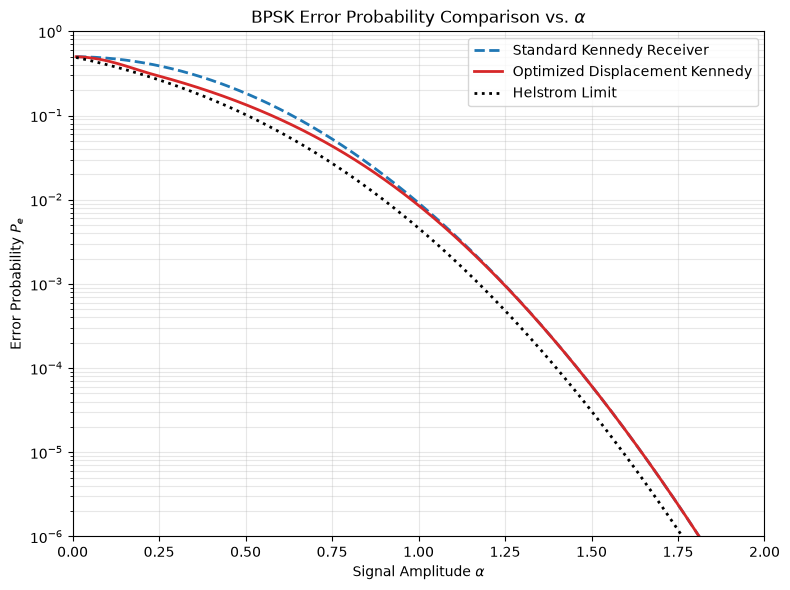

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# Parameter setup
alpha_vals = np.linspace(0.01, 2.0, 1000)


# 1. Optimal displacement (Generalized Kennedy) error probability
# P_err = 0.5 * (1 - np.exp(-beta**2) + np.exp(-(2*alpha + beta)**2))
def err_func(beta, alpha):
  return 0.5 * (1.0 - np.exp(-(beta**2)) + np.exp(-((2.0 * alpha + beta) ** 2)))


p_err_opt = []
for a in alpha_vals:
  res = sp.optimize.minimize_scalar(
      lambda b: err_func(b, a), bounds=(-2 * a, 2 * a), method="bounded"
  )
  p_err_opt.append(res.fun)
p_err_opt = np.array(p_err_opt)

# 2. Standard Kennedy receiver (beta = 0, exact nulling of one state)
p_err_kennedy = 0.5 * np.exp(-4 * alpha_vals**2)

# 3. Helstrom Bound for BPSK: 0.5 * (1 - sqrt(1 - e^(-4*alpha^2)))
overlap_sq = np.exp(-4 * alpha_vals**2)
p_err_helstrom = 0.5 * (1.0 - np.sqrt(1.0 - overlap_sq))

# Plotting
plt.figure(figsize=(8, 6))

plt.semilogy(
    alpha_vals,
    p_err_kennedy,
    label="Standard Kennedy Receiver",
    color="tab:blue",
    linestyle="--",
    lw=2,
)
plt.semilogy(
    alpha_vals,
    p_err_opt,
    label="Optimized Displacement Kennedy",
    color="tab:red",
    lw=2,
)
plt.semilogy(
    alpha_vals,
    p_err_helstrom,
    label="Helstrom Limit",
    color="black",
    linestyle=":",
    lw=2,
)

plt.xlim(0, 2.0)
plt.ylim(1e-6, 1)

plt.title(r"BPSK Error Probability Comparison vs. $\alpha$")
plt.xlabel(r"Signal Amplitude $\alpha$")
plt.ylabel(r"Error Probability $P_e$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def f2optimize(alpha, p0, p1):
    res = sp.optimize.minimize_scalar(
        lambda beta: p0 * (1 - np.exp(-(-alpha + beta)**2)) + p1 * (np.exp(-(alpha + beta)**2)), bounds=(-3 * alpha, 3 * alpha), method="bounded"
    )
    return res

def update_probabilities(p0,beta,alpha,click): #p0 is old hypothesis
    if click == 1:
        L0 = 1.0 - np.exp(-((alpha + beta) ** 2))
        L1 = 1.0 - np.exp(-((-alpha + beta) ** 2))
    else:
        L0 = np.exp(-((alpha + beta) ** 2))
        L1 = np.exp(-((-alpha + beta) ** 2))
    p0_new = L0 / (L0 + L1)

    return p0_new, 1-p0_new

def odds_optimized_dolinar(alpha, branches):
    res = sp.optimize.minimize_scalar(
            lambda b: f(b, a), bounds=(-3 * a, 3 * a), method="bounded"
        )
    # optimal_beta = res.x
    s
